In [1]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


TASK 1 – Data Loading, Cleaning & Exploratory Analysis

Step 1: Import all libraries 

In [2]:
import pandas as pd
print(pd.__version__)

3.0.3


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Set plot style globally

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

print('All libraries imported successfully!')

All libraries imported successfully!


Step 2: Load and combine all 12 CSV files into one DataFrame

In [4]:
# Path to the folder containing all CSV files

data_folder = 'data/'

# List all CSV files in the folder

all_files = [f for f in os.listdir(data_folder)
             if f.endswith('.csv')]

print(f'Found {len(all_files)} CSV files: {all_files}')

# Read each file and combine into one DataFrame

df_list = []

for file in all_files:
    filepath = os.path.join(data_folder, file)
    df_month = pd.read_csv(filepath)
    df_list.append(df_month)

# Concatenate (stack) all DataFrames vertically

df = pd.concat(df_list, ignore_index=True)

print(f'Combined DataFrame shape: {df.shape}')
print(f'Total rows: {len(df):,}')

df.head(3)

Found 12 CSV files: ['Sales_April_2019.csv', 'Sales_August_2019.csv', 'Sales_December_2019.csv', 'Sales_February_2019.csv', 'Sales_January_2019.csv', 'Sales_July_2019.csv', 'Sales_June_2019.csv', 'Sales_March_2019.csv', 'Sales_May_2019.csv', 'Sales_November_2019.csv', 'Sales_October_2019.csv', 'Sales_September_2019.csv']
Combined DataFrame shape: (185950, 9)
Total rows: 185,950


,Order ID,Product,Quantity Ordered,Price,Order Date,Time,Purchase Address,City,Product Type
0,176558,USB-C Charging Cable,2,11.95,2019-04-19,8:46 AM,"917 1st St, Dallas, TX 75001",Dallas,Cable
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07,10:30 PM,"682 Chestnut St, Boston, MA 02215",Boston,Headphones
2,176560,Google Phone,1,600,2019-04-12,2:38 PM,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,Phone


In [5]:
df.drop(columns=['Product Type'], errors='ignore', inplace=True)
df.drop(columns=['City'], errors='ignore', inplace=True)


df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df.columns.tolist())
df.reset_index(drop=True, inplace=True)
df.head()

['Order ID', 'Product', 'Quantity Ordered', 'Price', 'Order Date', 'Time', 'Purchase Address']


,Order ID,Product,Quantity Ordered,Price,Order Date,Time,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,2019-04-19,8:46 AM,"917 1st St, Dallas, TX 75001"
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07,10:30 PM,"682 Chestnut St, Boston, MA 02215"
2,176560,Google Phone,1,600,2019-04-12,2:38 PM,"669 Spruce St, Los Angeles, CA 90001"
3,176560,Wired Headphones,1,11.99,2019-04-12,2:38 PM,"669 Spruce St, Los Angeles, CA 90001"
4,176561,Wired Headphones,1,11.99,2019-04-30,9:27 AM,"333 8th St, Los Angeles, CA 90001"


In [6]:
print(df.head().to_string(index=False))

 Order ID                    Product  Quantity Ordered Price Order Date     Time                     Purchase Address
   176558       USB-C Charging Cable                 2 11.95 2019-04-19  8:46 AM         917 1st St, Dallas, TX 75001
   176559 Bose SoundSport Headphones                 1 99.99 2019-04-07 10:30 PM    682 Chestnut St, Boston, MA 02215
   176560               Google Phone                 1   600 2019-04-12  2:38 PM 669 Spruce St, Los Angeles, CA 90001
   176560           Wired Headphones                 1 11.99 2019-04-12  2:38 PM 669 Spruce St, Los Angeles, CA 90001
   176561           Wired Headphones                 1 11.99 2019-04-30  9:27 AM    333 8th St, Los Angeles, CA 90001


Step 3: Understand your data — always inspect before cleaning

In [7]:
# Basic information about the dataset

print('=== Shape ===')
print(df.shape)

print('\n=== Column Data Types ===')
print(df.dtypes)

print('\n=== Missing Values per Column ===')
print(df.isnull().sum())

print('\n=== Number of Duplicate Rows ===')
print(df.duplicated().sum())

print('\n=== Basic Statistics ===')
print(df.describe())

=== Shape ===
(185950, 7)

=== Column Data Types ===
Order ID                     int64
Product                        str
Quantity Ordered             int64
Price                          str
Order Date          datetime64[us]
Time                           str
Purchase Address               str
dtype: object

=== Missing Values per Column ===
Order ID            0
Product             0
Quantity Ordered    0
Price               0
Order Date          0
Time                0
Purchase Address    0
dtype: int64

=== Number of Duplicate Rows ===
264

=== Basic Statistics ===
            Order ID  Quantity Ordered                  Order Date
count  185950.000000     185950.000000                      185950
mean   230417.569379          1.124383  2019-07-18 07:00:22.109169
min    141234.000000          1.000000         2019-01-01 00:00:00
25%    185831.250000          1.000000         2019-04-16 00:00:00
50%    230367.500000          1.000000         2019-07-17 00:00:00
75%    275035.750000

Step 4: Clean the data — remove nulls, duplicates, and bad rows

In [8]:
# Step 4a: Remove rows where ALL values are NaN (blank separator rows)

df.dropna(how='all', inplace=True)
print(f'After removing all-NaN rows: {len(df):,} rows')

# Step 4b: Some rows have the header text repeated inside the data

# Example: Order ID column contains 'Order ID' as a value — remove these

df = df[df['Order ID'] != 'Order ID']
print(f'After removing repeated headers: {len(df):,} rows')

# Step 4c: Remove any remaining NaN rows

df.dropna(inplace=True)
print(f'After dropping remaining NaN rows: {len(df):,} rows')

# Step 4d: Remove duplicate rows

df.drop_duplicates(inplace=True)
print(f'After removing duplicates: {len(df):,} rows')

# Step 4e: Fix data types

df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price'] = pd.to_numeric(df['Price'].str.replace(',', '', regex=False))
df['Order Date'] = pd.to_datetime(df['Order Date'])
print('\nData types after cleaning:')
print(df.dtypes)


After removing all-NaN rows: 185,950 rows
After removing repeated headers: 185,950 rows
After dropping remaining NaN rows: 185,950 rows
After removing duplicates: 185,686 rows

Data types after cleaning:
Order ID                     int64
Product                        str
Quantity Ordered             int64
Price                      float64
Order Date          datetime64[us]
Time                           str
Purchase Address               str
dtype: object



Step 5: Feature Engineering — create new useful columns from existing ones


Feature engineering means creating new columns by combining or transforming existing ones. This is one of
the most important skills in data analysis.


In [9]:
# New column 1: Sales = Quantity * Price 
df['Sales'] = df['Quantity Ordered'] * df['Price']
print('Sales column created. Sample values:')
# print(df['Sales'].head())

# column 2: Month number (1=January, 12=December)
df['Month'] = df['Order Date'].dt.month

# New column 3: Month name for readable charts
# month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
# df['Month Name'] = df['Month'].map(month_names)

# New column 4: Hour of the day (0–23) 
df['Hour'] = df['Order Date'].dt.hour

# New column 5: City (extracted from Purchase Address) 
# Address format: '136 Church St, New York City, NY 10001'
# The city is the second part after splitting by comma

df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())

# Verify all new columns 
print(df[['Sales','Month','Hour','City',]].head(3))

Sales column created. Sample values:
    Sales  Month  Hour         City
0   23.90      4     0       Dallas
1   99.99      4     0       Boston
2  600.00      4     0  Los Angeles


Step 6: First analysis — answer key business questions with GroupBy

GroupBy is the most powerful tool in Pandas. It splits the data into groups, applies a function
(sum/count/mean), and combines the results.

In [13]:
#Q1: Which month had the highest sales? 

month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

monthly_sales['Month Name'] = monthly_sales['Month'].map(month_names)

monthly_sales = monthly_sales.sort_values('Month')

best_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax(),
    'Month Name'
]

best_sales = monthly_sales['Sales'].max()

print(f'Best month: {best_month} with ${best_sales:,.2f} in sales')

Best month: December with $4,608,295.70 in sales


In [40]:
# Q2: Which city had the most orders? 

city_orders = df.groupby('City')['Order ID'].count().reset_index()

city_orders.columns = ['City', 'Order Count']

city_orders = city_orders.sort_values('Order Count',ascending=False)

# Format Order Count with commas
city_orders['Order Count'] = city_orders['Order Count'].map('{:,}'.format)

print(city_orders.head(5).to_string(index=False))

         City Order Count
San Francisco      44,662
  Los Angeles      29,564
New York City      24,847
       Boston      19,901
      Atlanta      14,863


In [41]:
# Q3: Best hour of day for advertisements 

hourly_orders = (df.groupby('Hour')['Order ID'].count().reset_index())
hourly_orders.columns = ['Hour', 'Order Count']
#print(hourly_orders)

peak_hour = int(hourly_orders.loc[hourly_orders['Order Count'].idxmax(),'Hour'])
start_hour = (peak_hour - 1) % 24

print(
    f"Peak ordering hour: {peak_hour:02d}:00 "
    f"({start_hour:02d}:00 – {peak_hour:02d}:00 is best for ads)"
)

Peak ordering hour: 00:00 (23:00 – 00:00 is best for ads)


In [42]:
# Q4: Top 10 products by total revenue

product_revenue = df.groupby('Product')['Sales'].sum().reset_index()

product_revenue = product_revenue.sort_values('Sales', ascending=False)

# Format output
output = " | ".join(
    [f"{row['Product']}: ${row['Sales']:,.0f}"
     for _, row in product_revenue.head(10).iterrows()]
)

print(output)

Macbook Pro Laptop: $8,032,500 | iPhone: $4,792,900 | ThinkPad Laptop: $4,127,959 | Google Phone: $3,317,400 | 27in 4K Gaming Monitor: $2,433,148 | 34in Ultrawide Monitor: $2,352,898 | Apple Airpods Headphones: $2,345,550 | Flatscreen TV: $1,443,900 | Bose SoundSport Headphones: $1,342,866 | 27in FHD Monitor: $1,131,075


TASK 2 – Advanced Visualisation & Business Insights Report

Step 1: Monthly Sales Revenue — Line + Bar Chart

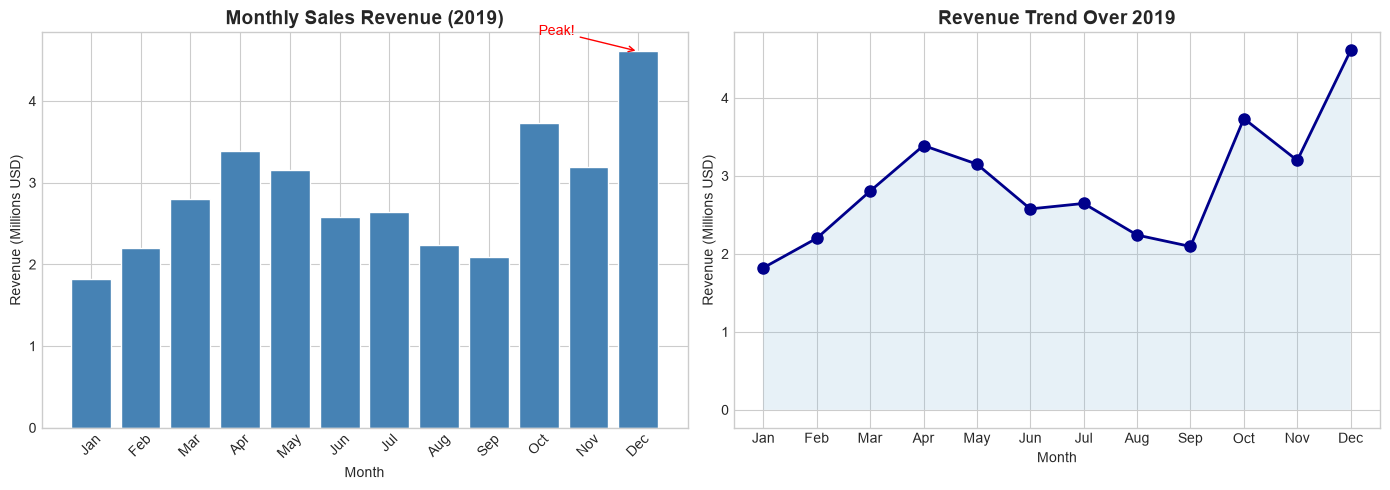

Chart 1 saved as chart1_monthly_sales.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left: Bar chart 

month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

monthly_sales['Month Name'] = monthly_sales['Month'].map(month_names)

axes[0].bar(
monthly_sales['Month Name'],monthly_sales['Sales'] / 1e6,
    color='steelblue',edgecolor='white')

axes[0].set_title('Monthly Sales Revenue (2019)',fontsize=14,fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (Millions USD)')
axes[0].tick_params(axis='x', rotation=45)

# Annotate the peak month
peak_idx = monthly_sales['Sales'].idxmax()
axes[0].annotate('Peak!',
xy=(peak_idx,monthly_sales['Sales'].max()/1e6),
xytext=(peak_idx-2,monthly_sales['Sales'].max()/1e6 + 0.2),
arrowprops=dict(arrowstyle='->',color='red'),
fontsize=10,color='red')

# Right: Line chart 
axes[1].plot(monthly_sales['Month'],monthly_sales['Sales'] / 1e6,
marker='o',linewidth=2,color='darkblue',markersize=8)

axes[1].fill_between(monthly_sales['Month'],monthly_sales['Sales']/1e6,alpha=0.2)
axes[1].set_title('Revenue Trend Over 2019',fontsize=14,fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (Millions USD)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(list(month_names.values()))

plt.tight_layout() 
# NOTE: plt.tight_layout() automatically adjusts spacing between subplots so labels don't overlap. Always add it before plt.savefig(). dpi=150 gives a high-resolution image suitable for reports.
plt.savefig('chart1_monthly_sales.png',dpi=150,bbox_inches='tight')
plt.show()
print('Chart 1 saved as chart1_monthly_sales.png')


Step 2: City Orders — Horizontal Bar Chart

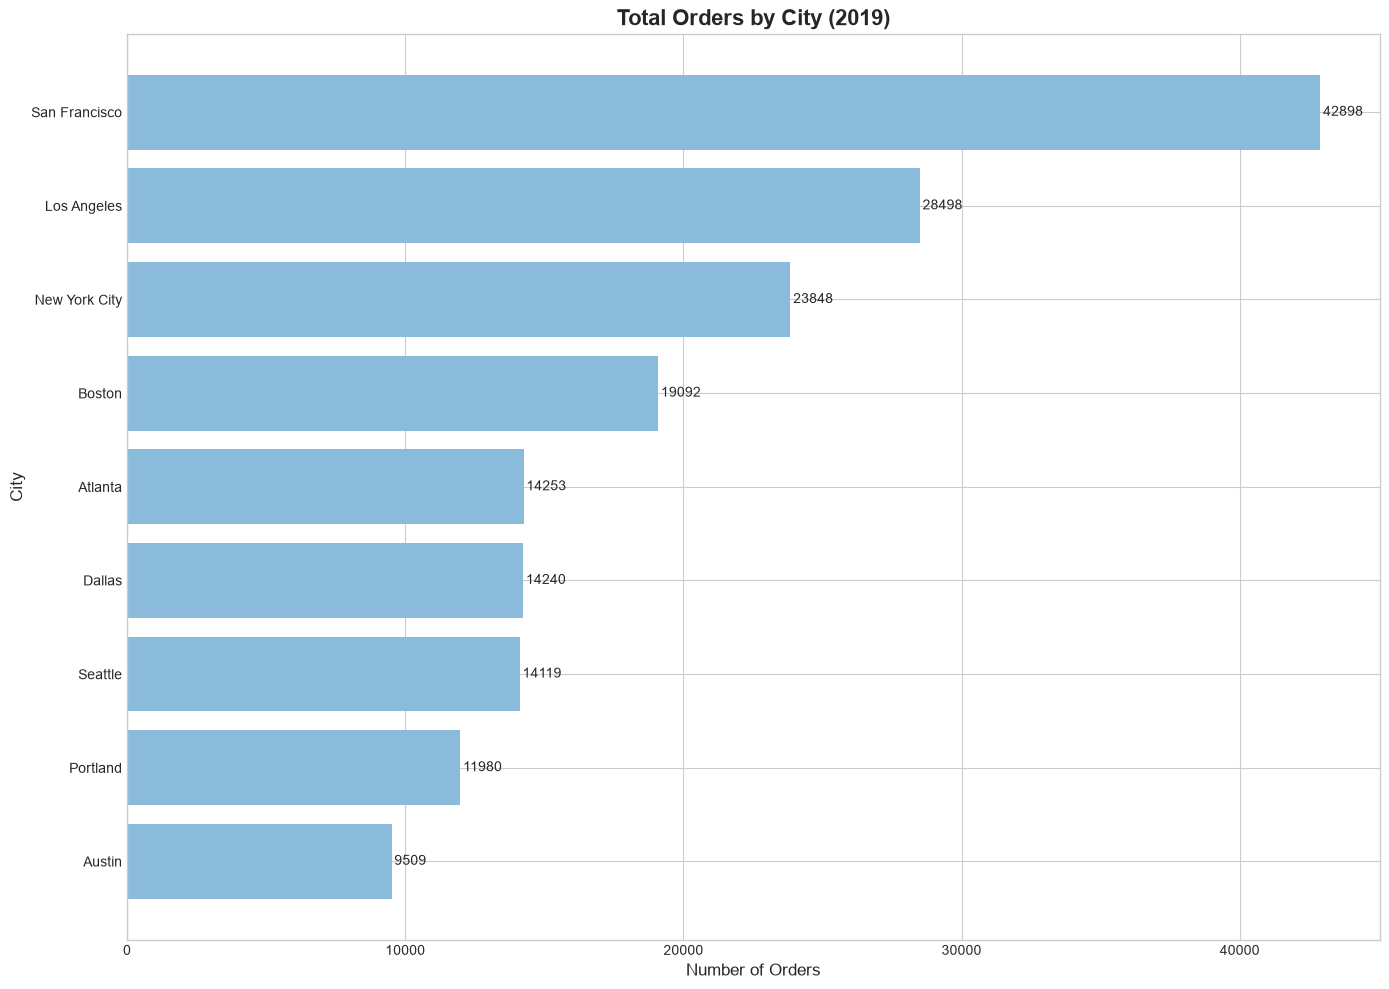

In [22]:
# Count orders by city
city_orders = df.groupby('City')['Order ID'].nunique().reset_index(name='Order Count')

import matplotlib.pyplot as plt

# Count orders by city
city_orders = df.groupby('City')['Order ID'].nunique().reset_index(name='Order Count')

plt.figure(figsize=(14, 10))

city_sorted = city_orders.sort_values('Order Count')

bars = plt.barh(
    city_sorted['City'],
    city_sorted['Order Count']
)

# Add value labels
for bar, val in zip(bars, city_sorted['Order Count']):
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        str(val),
        va='center'
    )

plt.title('Total Orders by City (2019)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('City', fontsize=12)

plt.tick_params(axis='both', labelsize=10)

plt.tight_layout()

plt.savefig(
    'chart2_city_orders.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Step 3: Best Advertisement Hour — Area + Vertical Lines


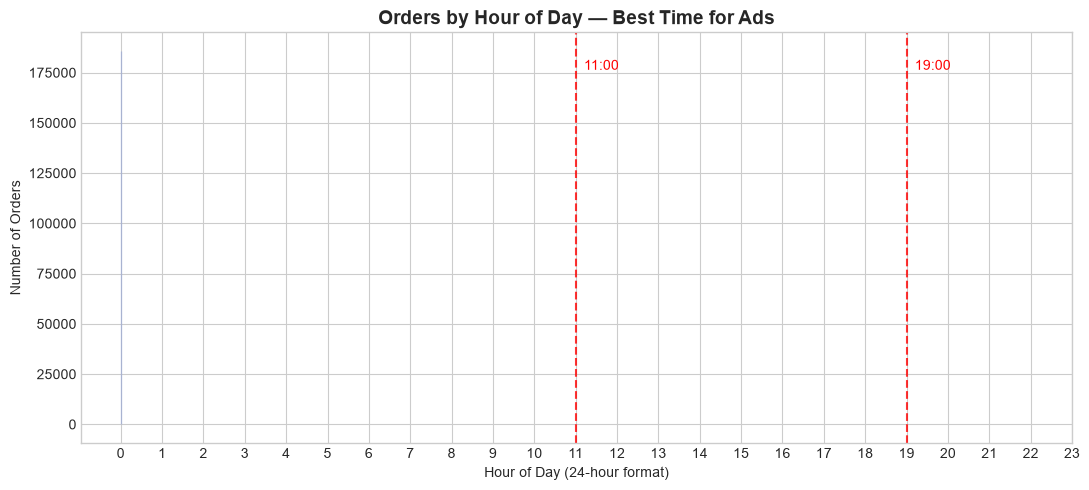

In [44]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_orders['Hour'],
    hourly_orders['Order Count'],
    color='royalblue',
    linewidth=2.5
)

plt.fill_between(
    hourly_orders['Hour'],
    hourly_orders['Order Count'],
    alpha=0.25,
    color='royalblue'
)

# Mark the two peak windows (before and after peak)
for h in [11, 19]:
    plt.axvline(
        x=h,
        color='red',
        linestyle='--',
        linewidth=1.5,
        alpha=0.8
    )

    plt.text(
        h + 0.2,
        hourly_orders['Order Count'].max() * 0.95,
        f'{h}:00',
        color='red',
        fontsize=10
    )

plt.title(
    'Orders by Hour of Day — Best Time for Ads',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.savefig('chart3_hourly_orders.png', dpi=150, bbox_inches='tight')
plt.show()

Step 4: Product Revenue — Styled Horizontal Bar + Seaborn Heatmap


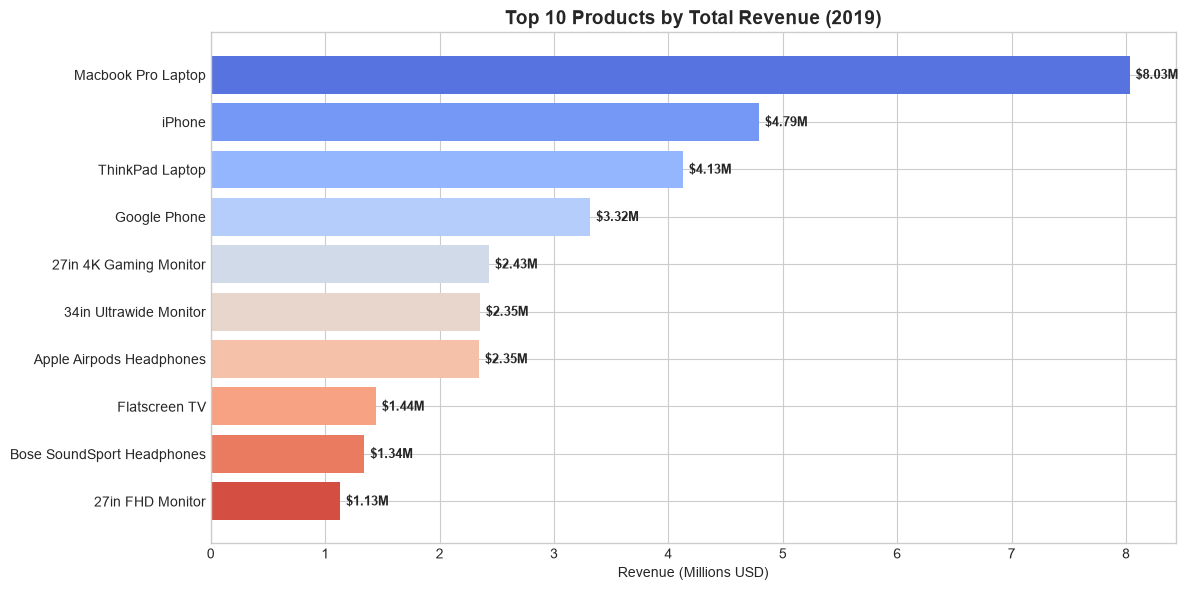

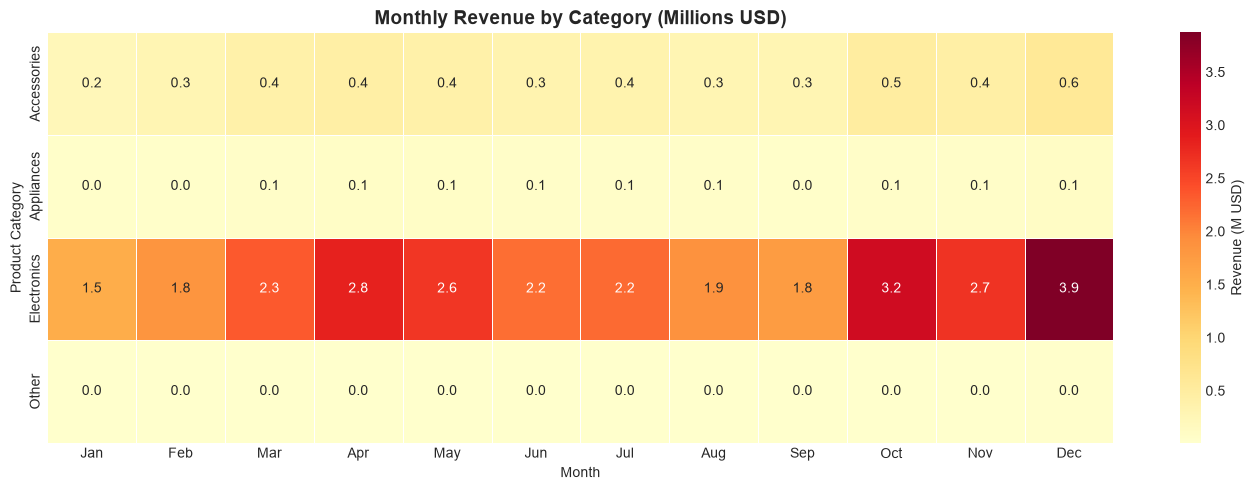

In [48]:
# Top 10 Products by Revenue

top10 = product_revenue.head(10)

plt.figure(figsize=(12, 6))

palette = sns.color_palette('coolwarm_r', 10)

bars = plt.barh(
    top10['Product'][::-1],
    top10['Sales'][::-1] / 1e6,
    color=palette
)

for bar, val in zip(
    bars,
    top10['Sales'][::-1] / 1e6
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'${val:.2f}M',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Top 10 Products by Total Revenue (2019)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Revenue (Millions USD)')

plt.tight_layout()

plt.savefig(
    'chart4_top_products.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# Heatmap: Monthly Revenue by Product Category

def get_category(product):
    if any(x in product for x in ['Laptop', 'Phone', 'iPhone', 'Monitor', 'TV']):
        return 'Electronics'
    elif any(x in product for x in ['Cable', 'Battery', 'Headphones', 'Earbuds']):
        return 'Accessories'
    elif any(x in product for x in ['Washing', 'Dryer', 'Fridge']):
        return 'Appliances'
    else:
        return 'Other'

# Create category column
df['Category'] = df['Product'].apply(get_category)

month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

df['Month Name'] = df['Month'].map(month_names)

# Pivot table
pivot = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Month Name',
    aggfunc='sum'
)

# Reorder months
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

pivot = pivot[month_order]

plt.figure(figsize=(14, 5))

sns.heatmap(
    pivot / 1e6,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Revenue (M USD)'}
)

plt.title(
    'Monthly Revenue by Category (Millions USD)',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('Product Category')
plt.xlabel('Month')

plt.tight_layout()

plt.savefig(
    'chart5_category_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Step 5: Quantity vs. Price — Scatter Plot to find the pattern

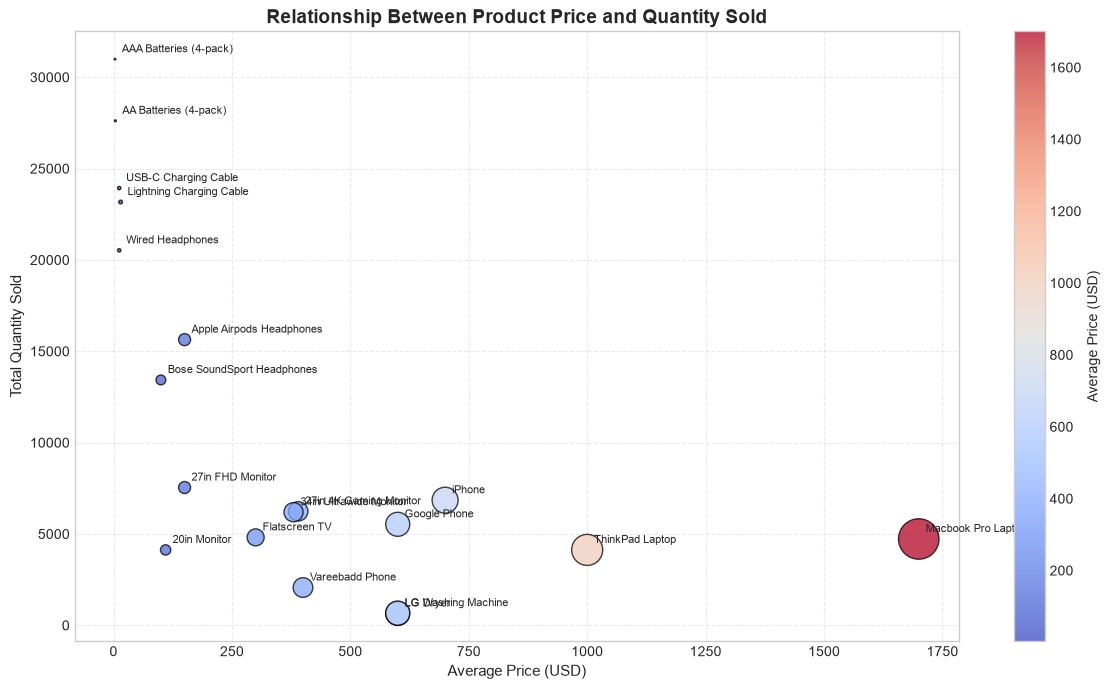

In [50]:
# Group by product: get average price and total quantity sold

# Price vs Quantity Sold Scatter Plot

product_stats = df.groupby('Product').agg(
    Avg_Price=('Price', 'mean'),
    Total_Qty=('Quantity Ordered', 'sum')
).reset_index()

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    product_stats['Avg_Price'],
    product_stats['Total_Qty'],
    s=product_stats['Avg_Price'] * 0.5,  # bubble size
    c=product_stats['Avg_Price'],        # color by price
    cmap='coolwarm',
    alpha=0.75,
    edgecolors='black'
)

# Add product labels
for _, row in product_stats.iterrows():
    plt.annotate(
        row['Product'],
        (row['Avg_Price'], row['Total_Qty']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

# Add color bar
plt.colorbar(
    scatter,
    label='Average Price (USD)'
)

plt.title(
    'Relationship Between Product Price and Quantity Sold',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Average Price (USD)', fontsize=11)
plt.ylabel('Total Quantity Sold', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    'chart6_price_vs_quantity.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# 📊 Business Insights Summary — E-Commerce Sales Analysis 2019

## 🔍 Key Findings

### 1. 🏆 December was the Best-Performing Month
- **Total Sales: $4.61 Million**
- December generated the **highest revenue** among all months.
- Holiday shopping, year-end promotions, and gift purchases significantly boosted sales.

### 2. 🌎 San Francisco Generated the Highest Number of Orders
- **Total Orders: 44,662**
- San Francisco emerged as the strongest market, indicating a large customer base and high purchasing power.

### 3. ⏰ Peak Customer Purchasing Hours
The highest order activity was observed at:

- **11:00 AM**
- **7:00 PM (19:00)**

These hours represent the periods when customers are most active and likely to make purchases.

### 4. 💻 MacBook Pro Laptop Generated the Highest Revenue
- **Total Revenue: $8.03 Million**
- Despite lower sales volume than accessories, its premium price contributed significantly to overall revenue.

### 5. 📈 Top Revenue-Generating Products

| Product | Revenue |
|----------|----------:|
| **MacBook Pro Laptop** | **$8.03M** |
| **iPhone** | **$4.79M** |
| **ThinkPad Laptop** | **$4.13M** |
| **Google Phone** | **$3.32M** |
| **27in 4K Gaming Monitor** | **$2.43M** |

### 6. 🔌 Accessories Recorded the Highest Unit Sales
- Charging cables, headphones, and batteries sold in the highest quantities.
- These products drive significant transaction volume and offer excellent cross-selling opportunities.

### 7. 📱 Electronics Dominate Revenue Contribution
- High-value electronic products contribute the majority of overall sales revenue.
- Smartphones, laptops, and monitors are the primary revenue drivers.

### 8. 📅 Q4 (October–December) Delivered the Strongest Performance
- The fourth quarter generated the highest sales momentum.
- Revenue steadily increased toward the holiday season, with **December reaching the annual peak**.

---




# 💡 Recommendations

### 1. 🚀 Launch Holiday Campaigns Earlier
- Start seasonal promotions from **October** instead of December.
- Capture early shoppers and maximize Q4 revenue opportunities.

### 2. 🎁 Promote Product Bundles
Bundle complementary products such as:
- **MacBook + Accessories**
- **Smartphones + Charging Cables**
- **Monitors + HDMI/USB-C Accessories**

This strategy can increase the **Average Order Value (AOV)**.

### 3. 📢 Optimize Advertising Schedule
Increase advertising spend during peak customer activity periods:

- **10:00 AM – 12:00 PM**
- **6:00 PM – 8:00 PM**

These time slots align with the highest purchasing activity.

### 4. 🏢 Strengthen Operations in High-Demand Cities
Prioritize inventory and logistics support in:

- **San Francisco**
- **Los Angeles**
- **New York City**

This can improve delivery speed and customer satisfaction.

### 5. 🔄 Implement Cross-Selling Strategies
- Recommend accessories during checkout.
- Offer discounted bundles with premium electronics.
- Increase revenue from high-volume accessory products.

### 6. 📦 Prepare Inventory for Q4 Demand
- Increase stock levels before October.
- Use historical sales trends for demand forecasting.
- Reduce stockout risk during peak sales periods.

---

# ✅ Conclusion

The **E-Commerce Sales Analysis 2019** reveals valuable insights into customer purchasing behavior, seasonal demand patterns, and product performance.

Key findings show that **December was the highest revenue-generating month**, **San Francisco recorded the largest number of orders**, and **MacBook Pro Laptop generated the highest product revenue**. Additionally, customer activity peaks around **11:00 AM** and **7:00 PM**, providing ideal opportunities for targeted advertising.

By focusing on **peak sales periods**, **high-performing products**, **bundle promotions**, and **inventory optimization**, the business can improve operational efficiency, enhance customer satisfaction, and drive sustainable revenue growth through data-driven decision-making.